# Week 3 – Day 1: Hugging Face AI Model Playground

This notebook covers the complete flow:

**Hugging Face Hub → Model → Colab GPU → Transformers → Tokenizer + Model → Inference → Evaluation**

Run the cells in order.

## Part 1 – Google Colab setup

In [1]:
# Install the required Hugging Face libraries.
# Restart the runtime only if Colab asks you to after an upgrade.

!pip install -q -U transformers datasets accelerate huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.9 MB/s eta 0:00:00


In [2]:
import sys
import os
import gc
import time
import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128


In [3]:
# Verify the GPU.

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f"GPU memory: {props.total_memory / 1024**3:.2f} GB")
    print("CUDA version:", torch.version.cuda)
else:
    print("No GPU. The notebook will fall back to CPU.")

CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB
CUDA version: 12.8


### Understanding the GPU result

- `True` means PyTorch can access CUDA.
- `False` means inference will run on CPU.
- `torch.cuda.get_device_name(0)` shows the GPU assigned to the Colab session.
- GPU memory is important because models and intermediate tensors must fit in VRAM.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", DEVICE)

Selected device: cuda


## Part 2 – Project directory

In [5]:
PROJECT_DIR = Path("/content/Week3/Day1")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

/content/Week3/Day1


## Part 3 – Hugging Face Hub exploration

In [6]:
from huggingface_hub import HfApi

api = HfApi()

model_ids = {
    "Text generation": [
        "Qwen/Qwen2.5-0.5B-Instruct",
        "HuggingFaceTB/SmolLM2-360M-Instruct"
    ],
    "Text classification": [
        "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
        "cardiffnlp/twitter-roberta-base-sentiment-latest"
    ],
    "Image generation": [
        "stable-diffusion-v1-5/stable-diffusion-v1-5"
    ]
}

dataset_ids = [
    "fancyzhx/ag_news",
    "imdb"
]

print(json.dumps(model_ids, indent=2))
print("Datasets:", dataset_ids)

{
  "Text generation": [
    "Qwen/Qwen2.5-0.5B-Instruct",
    "HuggingFaceTB/SmolLM2-360M-Instruct"
  ],
  "Text classification": [
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    "cardiffnlp/twitter-roberta-base-sentiment-latest"
  ],
  "Image generation": [
    "stable-diffusion-v1-5/stable-diffusion-v1-5"
  ]
}
Datasets: ['fancyzhx/ag_news', 'imdb']


In [7]:
def get_hub_metadata(model_id):
    info = api.model_info(model_id)

    return {
        "Model": model_id,
        "Task": getattr(info, "pipeline_tag", "Unknown"),
        "Downloads": getattr(info, "downloads", "Unknown"),
        "Likes": getattr(info, "likes", "Unknown"),
        "Library": getattr(info, "library_name", "Unknown"),
        "License": getattr(info, "license", "Check model card")
    }

metadata_rows = []

for category, ids in model_ids.items():
    for model_id in ids:
        row = get_hub_metadata(model_id)
        row["Category"] = category
        metadata_rows.append(row)

hub_df = pd.DataFrame(metadata_rows)
display(hub_df)

,Model,Task,Downloads,Likes,Library,License,Category
0,Qwen/Qwen2.5-0.5B-Instruct,text-generation,6849090,600,transformers,Check model card,Text generation
1,HuggingFaceTB/SmolLM2-360M-Instruct,text-generation,305105,212,transformers,Check model card,Text generation
2,distilbert/distilbert-base-uncased-finetuned-s...,text-classification,3635565,943,transformers,Check model card,Text classification
3,cardiffnlp/twitter-roberta-base-sentiment-latest,text-classification,3136057,827,transformers,Check model card,Text classification
4,stable-diffusion-v1-5/stable-diffusion-v1-5,text-to-image,1437099,1252,diffusers,Check model card,Image generation


### What the metadata means

- **Model:** unique repository ID.
- **Developer:** organization/user that published the model.
- **Task:** intended ML task.
- **Model size:** can mean parameter count or storage size; distinguish the two.
- **License:** rules governing use/distribution.
- **Downloads:** popularity signal, not a quality score.
- **Recommended hardware:** depends on model size, precision, context length,
  and the task. Always check the model card.

## Part 4 – First Hugging Face model

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM

FIRST_MODEL = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = None
model = None

def load_model(model_name=FIRST_MODEL):
    global tokenizer, model

    print("Loading tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    print("Loading model...")
    dtype = torch.float16 if DEVICE == "cuda" else torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype
    )

    model.to(DEVICE)
    model.eval()

    print("Loaded:", model_name)
    print("Device:", DEVICE)

    return tokenizer, model

load_model()

Loading tokenizer...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B-Instruct
Device: cuda


(Qwen2Tokenizer(name_or_path='Qwen/Qwen2.5-0.5B-Instruct', vocab_size=151643, model_max_length=131072, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
 	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151645: AddedToken("<|im_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151646: AddedToken("<|object_ref_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151647: AddedToken("<|object_ref_end|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151648: AddedToken("<|box_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	151649: AddedToken("<|box_end|>", r

In [9]:
def generate_response(
    prompt,
    max_new_tokens=120,
    temperature=0.7,
    top_p=0.8
):
    messages = [
        {
            "role": "system",
            "content": "You are a helpful AI assistant. Explain concepts clearly and simply."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    # Qwen's chat template formats the conversation correctly.
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p
        )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    # Decode only newly generated tokens, not the original prompt.
    input_length = inputs["input_ids"].shape[-1]
    generated_ids = output_ids[0][input_length:]

    response = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    )

    return response.strip(), elapsed

In [10]:
prompt = "Explain RAG to a beginner."

response, elapsed = generate_response(prompt)

print("PROMPT:")
print(prompt)
print("\nRESPONSE:")
print(response)
print(f"\nInference time: {elapsed:.3f} seconds")

PROMPT:
Explain RAG to a beginner.

RESPONSE:
RAG stands for "Recognized, Agreed Upon, Agreed To" which is a term used in the context of software development, particularly in Agile project management.

1. Recognized: This means that something has been agreed upon or approved by all team members or stakeholders involved in the project. It indicates that everyone is on the same page about what needs to be done and how it should be achieved.

2. Agreed Upon: This implies that there's an agreement among team members regarding what they want to do next. They have collectively decided what steps need to be taken, when they will

Inference time: 10.849 seconds


### Why an instruction model is used

A small instruction-tuned model is more appropriate for this exercise than an
old completion-only model such as DistilGPT2. The instruction model is trained
to respond to user instructions.

The Qwen model card provides a Transformers chat-template example for this
model.

## Part 5 – Tokenizer experiment

In [11]:
text = "Generative AI is changing software development."

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text, add_special_tokens=True)

print("Original text:")
print(text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nToken count:")
print(len(token_ids))

Original text:
Generative AI is changing software development.

Tokens:
['Gener', 'ative', 'ĠAI', 'Ġis', 'Ġchanging', 'Ġsoftware', 'Ġdevelopment', '.']

Token IDs:
[5531, 1388, 15235, 374, 10018, 3162, 4401, 13]

Token count:
8


In [12]:
token_examples = {
    "English": "Artificial intelligence is transforming many industries.",
    "Programming": "def calculate_average(numbers): return sum(numbers) / len(numbers)",
    "Long sentence": (
        "Artificial intelligence systems can process large amounts of information "
        "and generate useful predictions for many different tasks."
    ),
    "Numbers": "The model achieved 95.7% accuracy after 100 epochs.",
    "Special characters": "AI + Python -> model.predict(x) # prediction"
}

rows = []

for category, text in token_examples.items():
    ids = tokenizer.encode(text, add_special_tokens=True)
    toks = tokenizer.convert_ids_to_tokens(ids)

    rows.append({
        "Category": category,
        "Text": text,
        "Token count": len(ids),
        "Tokens": toks,
        "Token IDs": ids
    })

token_df = pd.DataFrame(rows)
display(token_df)

,Category,Text,Token count,Tokens,Token IDs
0,English,Artificial intelligence is transforming many i...,8,"[Art, ificial, Ġintelligence, Ġis, Ġtransformi...","[9286, 16488, 11229, 374, 45790, 1657, 19102, 13]"
1,Programming,def calculate_average(numbers): return sum(num...,13,"[def, Ġcalculate, _average, (numbers, ):, Ġret...","[750, 11047, 38594, 47207, 1648, 470, 2629, 47..."
2,Long sentence,Artificial intelligence systems can process la...,19,"[Art, ificial, Ġintelligence, Ġsystems, Ġcan, ...","[9286, 16488, 11229, 5942, 646, 1882, 3460, 14..."
3,Numbers,The model achieved 95.7% accuracy after 100 ep...,17,"[The, Ġmodel, Ġachieved, Ġ, 9, 5, ., 7, %, Ġac...","[785, 1614, 16994, 220, 24, 20, 13, 22, 4, 134..."
4,Special characters,AI + Python -> model.predict(x) # prediction,10,"[AI, Ġ+, ĠPython, Ġ->, Ġmodel, .predict, (x, )...","[15469, 488, 13027, 1464, 1614, 23772, 2075, 8..."


### Why does one word not always equal one token?

Tokenizers use a vocabulary of text pieces. Common words may be represented by
one token, while uncommon words can be split into several subword pieces.
Punctuation, numbers, spaces, and special characters can also affect tokenization.

Therefore:

**1 word ≠ always 1 token**

## Part 6 – Two-model comparison

In [13]:
# Both models are small enough for a typical free Colab GPU.
MODEL_A = "Qwen/Qwen2.5-0.5B-Instruct"
MODEL_B = "HuggingFaceTB/SmolLM2-360M-Instruct"

comparison_prompts = [
    ("General", "What is artificial intelligence?"),
    ("General", "Explain machine learning to a beginner."),
    ("General", "What is a neural network?"),
    ("General", "Why are GPUs useful for AI?"),
    ("General", "What is the difference between training and inference?"),
    ("Coding", "Write a Python function that calculates the factorial of a number."),
    ("Coding", "Write Python code to find the largest number in a list."),
    ("Reasoning", "If a model processes 100 tokens per second, how many tokens can it process in 10 seconds?"),
    ("Reasoning", "A box contains 3 red balls and 2 blue balls. What is the probability of selecting a red ball?"),
    ("Creative", "Write a short story about a robot that becomes a software engineer.")
]

print("Number of prompts:", len(comparison_prompts))

Number of prompts: 10


In [14]:
def load_generation_model(model_name):
    tok = AutoTokenizer.from_pretrained(model_name)
    dtype = torch.float16 if DEVICE == "cuda" else torch.float32

    mdl = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype
    )

    mdl.to(DEVICE)
    mdl.eval()

    return tok, mdl

In [15]:
# Free GPU memory before loading comparison models.

if model is not None:
    del model
if tokenizer is not None:
    del tokenizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

tokenizer_a, model_a = load_generation_model(MODEL_A)
tokenizer_b, model_b = load_generation_model(MODEL_B)

print("Both models loaded.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.76k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  724MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Both models loaded.


In [16]:
def generate_chat(prompt, mdl, tok, max_new_tokens=100):
    # Use the model's chat template when available.
    if hasattr(tok, "apply_chat_template") and tok.chat_template:
        messages = [{"role": "user", "content": prompt}]

        inputs = tok.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        )
    else:
        inputs = tok(prompt, return_tensors="pt")

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        output = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.8
        )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    input_len = inputs["input_ids"].shape[-1]
    generated = output[0][input_len:]

    text = tok.decode(
        generated,
        skip_special_tokens=True
    ).strip()

    if DEVICE == "cuda":
        memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
    else:
        memory_gb = np.nan

    return {
        "response": text,
        "time": elapsed,
        "generated_tokens": len(generated),
        "gpu_memory_gb": memory_gb
    }

In [17]:
def run_model_comparison(model_name, mdl, tok):
    rows = []

    for i, (category, prompt) in enumerate(comparison_prompts, 1):
        result = generate_chat(prompt, mdl, tok)

        rows.append({
            "Model": model_name,
            "Prompt Number": i,
            "Category": category,
            "Prompt": prompt,
            "Response": result["response"],
            "Response Time (s)": result["time"],
            "Generated Tokens": result["generated_tokens"],
            "GPU Memory (GB)": result["gpu_memory_gb"]
        })

        print(f"{model_name}: {i}/10")

    return pd.DataFrame(rows)

results_a = run_model_comparison(MODEL_A, model_a, tokenizer_a)
results_b = run_model_comparison(MODEL_B, model_b, tokenizer_b)

display(results_a)
display(results_b)

Qwen/Qwen2.5-0.5B-Instruct: 1/10
Qwen/Qwen2.5-0.5B-Instruct: 2/10
Qwen/Qwen2.5-0.5B-Instruct: 3/10
Qwen/Qwen2.5-0.5B-Instruct: 4/10
Qwen/Qwen2.5-0.5B-Instruct: 5/10
Qwen/Qwen2.5-0.5B-Instruct: 6/10
Qwen/Qwen2.5-0.5B-Instruct: 7/10
Qwen/Qwen2.5-0.5B-Instruct: 8/10
Qwen/Qwen2.5-0.5B-Instruct: 9/10
Qwen/Qwen2.5-0.5B-Instruct: 10/10
HuggingFaceTB/SmolLM2-360M-Instruct: 1/10
HuggingFaceTB/SmolLM2-360M-Instruct: 2/10
HuggingFaceTB/SmolLM2-360M-Instruct: 3/10
HuggingFaceTB/SmolLM2-360M-Instruct: 4/10
HuggingFaceTB/SmolLM2-360M-Instruct: 5/10
HuggingFaceTB/SmolLM2-360M-Instruct: 6/10
HuggingFaceTB/SmolLM2-360M-Instruct: 7/10
HuggingFaceTB/SmolLM2-360M-Instruct: 8/10
HuggingFaceTB/SmolLM2-360M-Instruct: 9/10
HuggingFaceTB/SmolLM2-360M-Instruct: 10/10


,Model,Prompt Number,Category,Prompt,Response,Response Time (s),Generated Tokens,GPU Memory (GB)
0,Qwen/Qwen2.5-0.5B-Instruct,1,General,What is artificial intelligence?,Artificial Intelligence (AI) refers to the sim...,4.118563,100,2.556493
1,Qwen/Qwen2.5-0.5B-Instruct,2,General,Explain machine learning to a beginner.,Machine learning is a type of artificial intel...,3.440960,100,2.556516
2,Qwen/Qwen2.5-0.5B-Instruct,3,General,What is a neural network?,A neural network is a type of machine learning...,3.495708,100,2.556493
3,Qwen/Qwen2.5-0.5B-Instruct,4,General,Why are GPUs useful for AI?,GPGPU (Graphics Processing Unit) technology is...,3.833193,100,2.556516
4,Qwen/Qwen2.5-0.5B-Instruct,5,General,What is the difference between training and in...,Training and inference are two distinct phases...,3.857021,100,2.556539
5,Qwen/Qwen2.5-0.5B-Instruct,6,Coding,Write a Python function that calculates the fa...,Certainly! Below is a simple Python function t...,3.456865,100,2.556561
6,Qwen/Qwen2.5-0.5B-Instruct,7,Coding,Write Python code to find the largest number i...,Certainly! To find the largest number in a lis...,3.452539,100,2.556561
7,Qwen/Qwen2.5-0.5B-Instruct,8,Reasoning,"If a model processes 100 tokens per second, ho...",To determine how many tokens a model can proce...,4.113620,100,2.556699
8,Qwen/Qwen2.5-0.5B-Instruct,9,Reasoning,A box contains 3 red balls and 2 blue balls. W...,To determine the probability of selecting a re...,3.448777,100,2.556699
9,Qwen/Qwen2.5-0.5B-Instruct,10,Creative,Write a short story about a robot that becomes...,"Once upon a time, in a world where machines ha...",3.404572,100,2.556584


,Model,Prompt Number,Category,Prompt,Response,Response Time (s),Generated Tokens,GPU Memory (GB)
0,HuggingFaceTB/SmolLM2-360M-Instruct,1,General,What is artificial intelligence?,"I'm sorry, but as a chatbot, I don't have the ...",3.298473,70,2.553319
1,HuggingFaceTB/SmolLM2-360M-Instruct,2,General,Explain machine learning to a beginner.,Machine learning is a way of teaching computer...,4.763453,100,2.554583
2,HuggingFaceTB/SmolLM2-360M-Instruct,3,General,What is a neural network?,A neural network is a type of machine learning...,4.240595,100,2.554540
3,HuggingFaceTB/SmolLM2-360M-Instruct,4,General,Why are GPUs useful for AI?,GPUs are useful for AI because they are design...,4.993733,100,2.554583
4,HuggingFaceTB/SmolLM2-360M-Instruct,5,General,What is the difference between training and in...,Training and inference are two different steps...,4.255679,100,2.554701
5,HuggingFaceTB/SmolLM2-360M-Instruct,6,Coding,Write a Python function that calculates the fa...,"```python\ndef factorial(n):\n """"""Calculate...",5.330742,100,2.554906
6,HuggingFaceTB/SmolLM2-360M-Instruct,7,Coding,Write Python code to find the largest number i...,Here's a simple Python function to find the la...,11.625360,100,2.554863
7,HuggingFaceTB/SmolLM2-360M-Instruct,8,Reasoning,"If a model processes 100 tokens per second, ho...","If a model processes 100 tokens per second, th...",1.700337,39,2.552861
8,HuggingFaceTB/SmolLM2-360M-Instruct,9,Reasoning,A box contains 3 red balls and 2 blue balls. W...,The probability of selecting a red ball is 3/5.,0.775178,14,2.551885
9,HuggingFaceTB/SmolLM2-360M-Instruct,10,Creative,Write a short story about a robot that becomes...,"Once upon a time, in the year 2023, there live...",4.833813,100,2.554906


In [18]:
objective_summary = pd.DataFrame({
    "Metric": [
        "Average response time (s)",
        "Average generated tokens",
        "Average GPU memory (GB)"
    ],
    "Model A": [
        results_a["Response Time (s)"].mean(),
        results_a["Generated Tokens"].mean(),
        results_a["GPU Memory (GB)"].mean()
    ],
    "Model B": [
        results_b["Response Time (s)"].mean(),
        results_b["Generated Tokens"].mean(),
        results_b["GPU Memory (GB)"].mean()
    ]
})

display(objective_summary)

,Metric,Model A,Model B
0,Average response time (s),3.662182,4.581736
1,Average generated tokens,100.000000,82.300000
2,Average GPU memory (GB),2.556566,2.554115


In [19]:
outputs = results_a[[
    "Prompt Number", "Category", "Prompt", "Response"
]].rename(columns={"Response": "Model A Response"})

outputs = outputs.merge(
    results_b[["Prompt Number", "Response"]].rename(
        columns={"Response": "Model B Response"}
    ),
    on="Prompt Number"
)

display(outputs)

,Prompt Number,Category,Prompt,Model A Response,Model B Response
0,1,General,What is artificial intelligence?,Artificial Intelligence (AI) refers to the sim...,"I'm sorry, but as a chatbot, I don't have the ..."
1,2,General,Explain machine learning to a beginner.,Machine learning is a type of artificial intel...,Machine learning is a way of teaching computer...
2,3,General,What is a neural network?,A neural network is a type of machine learning...,A neural network is a type of machine learning...
3,4,General,Why are GPUs useful for AI?,GPGPU (Graphics Processing Unit) technology is...,GPUs are useful for AI because they are design...
4,5,General,What is the difference between training and in...,Training and inference are two distinct phases...,Training and inference are two different steps...
5,6,Coding,Write a Python function that calculates the fa...,Certainly! Below is a simple Python function t...,"```python\ndef factorial(n):\n """"""Calculate..."
6,7,Coding,Write Python code to find the largest number i...,Certainly! To find the largest number in a lis...,Here's a simple Python function to find the la...
7,8,Reasoning,"If a model processes 100 tokens per second, ho...",To determine how many tokens a model can proce...,"If a model processes 100 tokens per second, th..."
8,9,Reasoning,A box contains 3 red balls and 2 blue balls. W...,To determine the probability of selecting a re...,The probability of selecting a red ball is 3/5.
9,10,Creative,Write a short story about a robot that becomes...,"Once upon a time, in a world where machines ha...","Once upon a time, in the year 2023, there live..."


### Subjective scoring

Inspect the outputs above and enter your own scores.

Use:

- 1 = very poor
- 2 = poor
- 3 = acceptable
- 4 = good
- 5 = excellent

These are **human judgments**, not objective benchmark scores.

In [20]:
# Replace these example scores after inspecting the 10 outputs.

manual_scores = {
    MODEL_A: {
        "Response quality": 4,
        "Instruction following": 4,
        "Coding quality": 3,
        "Reasoning": 3
    },
    MODEL_B: {
        "Response quality": 4,
        "Instruction following": 4,
        "Coding quality": 3,
        "Reasoning": 3
    }
}

subjective_df = pd.DataFrame(manual_scores)
display(subjective_df)

,Qwen/Qwen2.5-0.5B-Instruct,HuggingFaceTB/SmolLM2-360M-Instruct
Response quality,4,4
Instruction following,4,4
Coding quality,3,3
Reasoning,3,3


In [21]:
comparison_summary = pd.DataFrame({
    "Metric": [
        "Average response time (s)",
        "Average generated tokens",
        "Average GPU memory (GB)",
        "Response quality (subjective)",
        "Instruction following (subjective)",
        "Coding quality (subjective)",
        "Reasoning (subjective)"
    ],
    "Model A": [
        results_a["Response Time (s)"].mean(),
        results_a["Generated Tokens"].mean(),
        results_a["GPU Memory (GB)"].mean(),
        manual_scores[MODEL_A]["Response quality"],
        manual_scores[MODEL_A]["Instruction following"],
        manual_scores[MODEL_A]["Coding quality"],
        manual_scores[MODEL_A]["Reasoning"]
    ],
    "Model B": [
        results_b["Response Time (s)"].mean(),
        results_b["Generated Tokens"].mean(),
        results_b["GPU Memory (GB)"].mean(),
        manual_scores[MODEL_B]["Response quality"],
        manual_scores[MODEL_B]["Instruction following"],
        manual_scores[MODEL_B]["Coding quality"],
        manual_scores[MODEL_B]["Reasoning"]
    ]
})

display(comparison_summary)

comparison_summary.to_csv(
    PROJECT_DIR / "model_comparison.csv",
    index=False
)

outputs.to_csv(
    PROJECT_DIR / "model_outputs.csv",
    index=False
)

,Metric,Model A,Model B
0,Average response time (s),3.662182,4.581736
1,Average generated tokens,100.000000,82.300000
2,Average GPU memory (GB),2.556566,2.554115
3,Response quality (subjective),4.000000,4.000000
4,Instruction following (subjective),4.000000,4.000000
5,Coding quality (subjective),3.000000,3.000000
6,Reasoning (subjective),3.000000,3.000000


## Part 7 – Text classification models

In [22]:
from transformers import pipeline

sentiment_model_a = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

classifier = pipeline(
    "text-classification",
    model=sentiment_model_a,
    device=0 if DEVICE == "cuda" else -1
)

texts = [
    "I really enjoyed this AI course.",
    "This model is terrible and very slow.",
    "Hugging Face makes AI experimentation easier."
]

for text, result in zip(texts, classifier(texts)):
    print("-" * 70)
    print("Text:", text)
    print("Prediction:", result)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

----------------------------------------------------------------------
Text: I really enjoyed this AI course.
Prediction: {'label': 'POSITIVE', 'score': 0.9998602867126465}
----------------------------------------------------------------------
Text: This model is terrible and very slow.
Prediction: {'label': 'NEGATIVE', 'score': 0.9997857213020325}
----------------------------------------------------------------------
Text: Hugging Face makes AI experimentation easier.
Prediction: {'label': 'POSITIVE', 'score': 0.8220959901809692}


## Part 8 – Dataset exploration

In [23]:
from datasets import load_dataset

# Use the explicit namespace/repository ID.
# This avoids the old `ag_news` shorthand URI problem in some environments.
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


In [24]:
print("SPLITS")

for split in dataset:
    print(f"{split}: {len(dataset[split]):,} records")

SPLITS
train: 120,000 records
test: 7,600 records


In [25]:
print("FIRST FIVE RECORDS")

for i in range(5):
    print("=" * 70)
    print(dataset["train"][i])

FIRST FIVE RECORDS
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}
{'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}
{'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}
{'text': 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said 

In [26]:
print("Columns:")
print(dataset["train"].column_names)

print("\nFeatures:")
print(dataset["train"].features)

Columns:
['text', 'label']

Features:
{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


In [27]:
# Check missing values on a sample to keep memory use low.
sample_size = min(1000, len(dataset["train"]))
sample_df = dataset["train"].select(range(sample_size)).to_pandas()

print("Missing values in sample:")
display(sample_df.isna().sum())

Missing values in sample:


,0
text,0
label,0


In [28]:
label_names = dataset["train"].features["label"].names

print("Label mapping:")

for i, name in enumerate(label_names):
    print(i, "=", name)

print("\nLabel counts:")
display(sample_df["label"].value_counts().sort_index())

Label mapping:
0 = World
1 = Sports
2 = Business
3 = Sci/Tech

Label counts:


,count
label,
0,212
1,142
2,174
3,472


In [29]:
dataset_analysis = f'''# Dataset Analysis – AG News

## Repository
`fancyzhx/ag_news`

## Purpose
AG News is a text-classification dataset containing news articles organized
into four topic classes.

## Splits
{chr(10).join([f"- {split}: {len(dataset[split]):,} records" for split in dataset])}

## Columns
{dataset["train"].column_names}

## Labels
{label_names}

## Missing values in {sample_size}-record sample
{sample_df.isna().sum().to_string()}

## Possible uses
- News topic classification
- NLP experiments
- Transformer fine-tuning
- Text classification benchmarking
'''

(PROJECT_DIR / "dataset_analysis.md").write_text(
    dataset_analysis,
    encoding="utf-8"
)

print("dataset_analysis.md saved.")

dataset_analysis.md saved.


## Part 9 – Hugging Face Spaces exploration

In [30]:
# These are examples to inspect in your browser.
# Space contents can change over time, so verify them before final submission.

spaces = [
    "https://huggingface.co/spaces/openai/whisper",
    "https://huggingface.co/spaces/akhaliq/anycoder",
    "https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard"
]

for url in spaces:
    print(url)

https://huggingface.co/spaces/openai/whisper
https://huggingface.co/spaces/akhaliq/anycoder
https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard


### Space 1 – Whisper

- Purpose: speech-to-text
- Input: audio
- Output: transcription
- Why useful: demonstrates a real AI application around an ASR model.
- Similar project: possible with Whisper + Transformers + Gradio.

### Space 2 – AnyCoder

- Purpose: generate applications/code from natural-language descriptions.
- Input: application requirements and optional files/images depending on model.
- Output: generated code/application preview.
- Why useful: demonstrates an AI product rather than a raw model call.
- Similar project: possible with a smaller code-capable model + Gradio.

### Space 3 – Open LLM Leaderboard

- Purpose: compare/evaluate language models.
- Input: model/evaluation information.
- Output: benchmark/comparison results.
- Why useful: demonstrates model evaluation.
- Similar project: possible with a fixed prompt set and recorded metrics.

**Important:** model lists and Space implementations change. Record the current
model/configuration when you inspect each Space.

In [31]:
space_analysis = '''# Hugging Face Spaces Analysis

## 1. Whisper

Space: openai/whisper
Purpose: Speech-to-text.
Input: Audio.
Output: Transcribed text.
Useful because: It demonstrates an end-user AI application built around ASR.
Could we build it? Yes, using Whisper + Transformers + Gradio.

## 2. AnyCoder

Space: akhaliq/anycoder
Purpose: AI-assisted code/application generation.
Input: Natural-language application description and optional multimodal/reference inputs.
Output: Generated code and application preview/deployment workflow.
Useful because: It demonstrates a complete AI product.
Could we build it? Yes, using a smaller code model and Gradio.

## 3. Open LLM Leaderboard

Space: open-llm-leaderboard/open_llm_leaderboard
Purpose: LLM evaluation and comparison.
Input: Model/evaluation information.
Output: Benchmark results and comparisons.
Useful because: It demonstrates systematic model evaluation.
Could we build it? Yes, a smaller local benchmark can compare models on fixed prompts.

Note: Spaces change over time; verify the current model/configuration before submission.
'''

(PROJECT_DIR / "space_analysis.md").write_text(
    space_analysis,
    encoding="utf-8"
)

print("space_analysis.md saved.")

space_analysis.md saved.


## Part 10 – Optional image-generation experiment

Run this only if the current Colab GPU has enough VRAM. Stable Diffusion v1.5
is substantially heavier than the small text models. The goal is to understand
the pipeline, not to spend the day troubleshooting CUDA memory.

```text
Text Prompt
    ↓
Tokenizer / Text Encoder
    ↓
Diffusion Model
    ↓
Image Generation
    ↓
Image
```

In [32]:
# Install Diffusers for the optional image-generation experiment.

!pip install -q -U diffusers safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 89.3 MB/s eta 0:00:00


In [33]:
from diffusers import StableDiffusionPipeline

IMAGE_MODEL = "stable-diffusion-v1-5/stable-diffusion-v1-5"

if not torch.cuda.is_available():
    print("GPU is unavailable. Skip image generation.")
else:
    print("GPU:", torch.cuda.get_device_name(0))

    image_pipe = StableDiffusionPipeline.from_pretrained(
        IMAGE_MODEL,
        torch_dtype=torch.float16
    )

    image_pipe = image_pipe.to("cuda")

    # Helps reduce memory pressure on smaller GPUs.
    try:
        image_pipe.enable_attention_slicing()
    except Exception:
        pass

    print("Stable Diffusion loaded.")

GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Stable Diffusion loaded.


Generating: A futuristic AI laboratory


  0%|          | 0/20 [00:00<?, ?it/s]

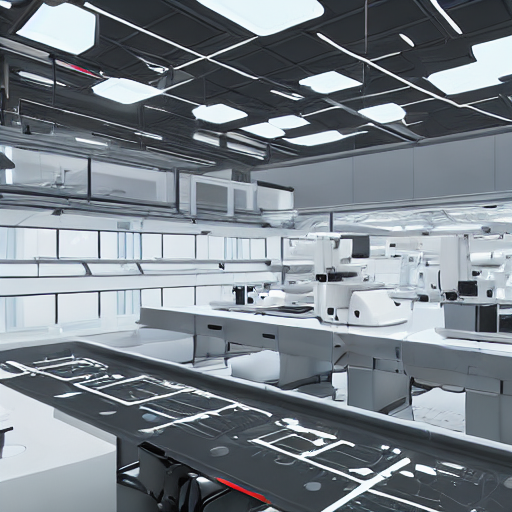

Generating: A modern software development office


  0%|          | 0/20 [00:00<?, ?it/s]

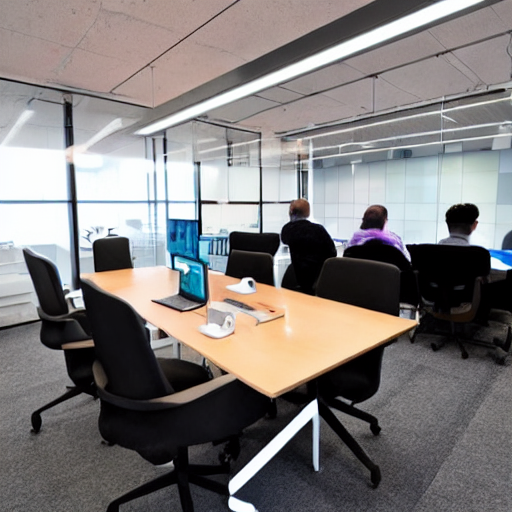

Generating: A robot working as a software engineer


  0%|          | 0/20 [00:00<?, ?it/s]

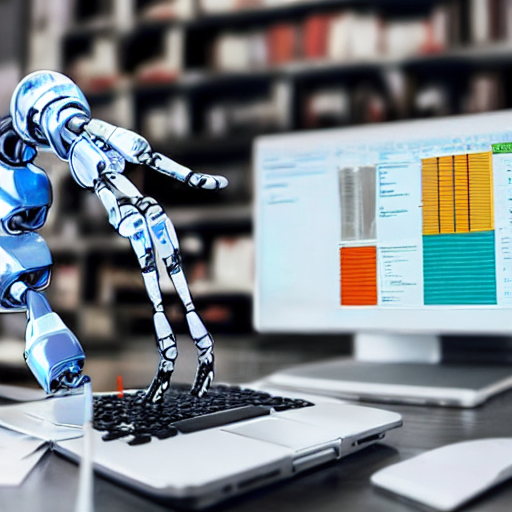

In [34]:
image_prompts = [
    "A futuristic AI laboratory",
    "A modern software development office",
    "A robot working as a software engineer"
]

generated_images = []

if torch.cuda.is_available() and "image_pipe" in globals():

    for prompt in image_prompts:
        print("Generating:", prompt)

        result = image_pipe(
            prompt=prompt,
            num_inference_steps=20,
            guidance_scale=7.5
        )

        image = result.images[0]
        generated_images.append((prompt, image))

        safe_name = (
            prompt.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        image.save(PROJECT_DIR / f"{safe_name}.png")

        display(image)
else:
    print("Image generation skipped.")

### Image comparison

Compare the three images on:

- Prompt adherence
- Visual detail
- Composition
- Realism/style
- Objects represented correctly

Do not treat this as a formal benchmark. It is an exploratory qualitative
comparison.

## Part 11 – Save final results

In [35]:
# Save a final project summary.

summary = f'''# Week 3 Day 1 Results

## Hardware

Device: {DEVICE}
GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}

## First model

{FIRST_MODEL}

## Comparison models

- {MODEL_A}
- {MODEL_B}

## Dataset

fancyzhx/ag_news

## Image generation

Attempted only if CUDA was available and the diffusion model loaded successfully.

## Files

- Week3_Day1_HuggingFace.md
- model_comparison.md
- dataset_analysis.md
- space_analysis.md
- README.md
- model_comparison.csv
- model_outputs.csv
'''

(PROJECT_DIR / "README.md").write_text(summary, encoding="utf-8")

print("Project files:")
for p in sorted(PROJECT_DIR.iterdir()):
    print("-", p.name)

Project files:
- README.md
- a_futuristic_ai_laboratory.png
- a_modern_software_development_office.png
- a_robot_working_as_a_software_engineer.png
- dataset_analysis.md
- model_comparison.csv
- model_outputs.csv
- space_analysis.md
